In [1]:
import sys
sys.path.append("../")

# local imports
from batchAQUA_general import batchAQUA
from AQUA_general import AQUA
from stimulus import *
from plotting_functions import *

# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
IB = {'name': 'IB', 'C': 150, 'k': 1.2, 'v_r': -75, 'v_t': -45, 'v_peak': 50,
     'a': 0.01, 'b': 5, 'c': -56, 'd': 130, 'e': 0., 'f': 0., 'tau': 0.}
    
IB_aut = {'name': 'IB', 'C': 150, 'k': 1.2, 'v_r': -75, 'v_t': -45, 'v_peak': 50,
     'a': 0.01, 'b': 5, 'c': -56, 'd': 130, 'e': 0.2, 'f': 150., 'tau': 0.}

100%|██████████| 99999/99999 [00:10<00:00, 9239.65it/s]


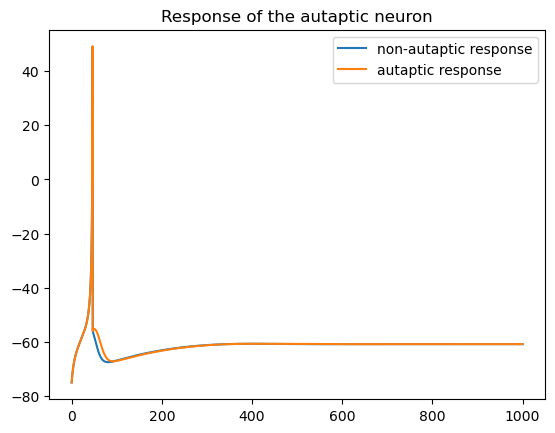

In [10]:
### INPUT is flat

threshold = 340  # approx

T = 1000         # ms
dt = 0.01        # ms
N_iter = int(T/dt)

freq = 3 # Hz (Kepecs et al.)
amp = 75
phase = 0

x_ini = np.array([IB["v_r"], 0, 0])

I_inj = threshold*np.ones((2, N_iter))

# pick params here
params = [IB, IB_aut]


batch = batchAQUA(params) 
batch.Initialise(np.array([x_ini, x_ini]), np.zeros(len(params)))

# simulate
X_flat, time, _ = batch.update_batch(dt, N_iter, I_inj)

# plot output
label = 'non-autaptic response'
plt.plot(time, X_flat[0, 0, :], label = label)

# plot output
label = 'autaptic response'
plt.plot(time, X_flat[1, 0, :], label = label)
plt.title("Response of the autaptic neuron")

plt.legend()
plt.show()

In [4]:
### INPUT is a sinusoid

threshold = 400  # approx

T = 1000         # ms
dt = 0.01        # ms
N_iter = int(T/dt)

freq = 3 # Hz (Kepecs et al.)
amp = 75
phase = 0

x_ini = np.array([-60, 0, 0])

I_sin, _ = sinusoid(N_iter, dt, freq, amp, phase)
I_sin += threshold + amp

I_inj = np.array([I_sin, I_sin])

# pick params here
params = [IB, IB_aut]

batch = batchAQUA(params) 
batch.Initialise(np.array([x_ini, x_ini]), np.zeros(len(params)))

# simulate
X_sin, time, spikes_sin = batch.update_batch(dt, N_iter, I_inj)

100%|██████████| 99999/99999 [00:10<00:00, 9566.65it/s]


TypeError: plot_potential_versus_injected() got an unexpected keyword argument 'fig'

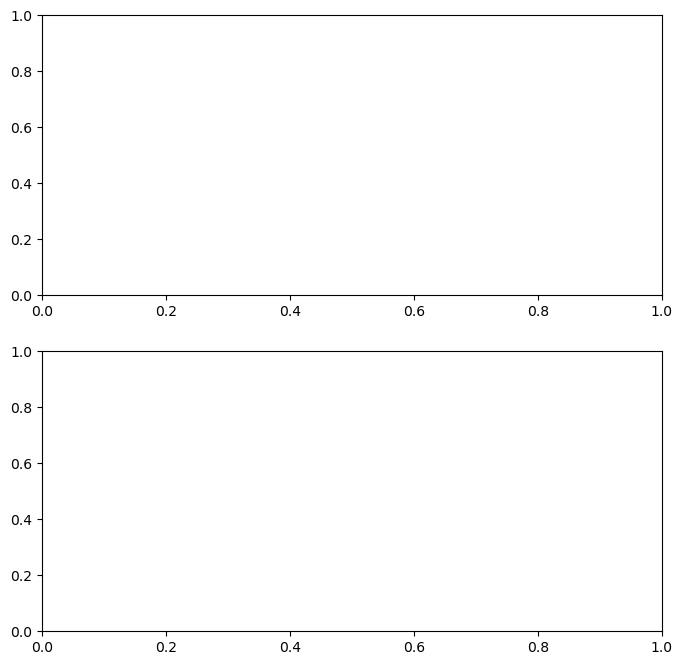

In [5]:
fig, ax = plt.subplots(2, 1, figsize = (8, 8))

# plot output
label = 'non-autaptic response'
fig, ax = plot_potential_versus_injected(X_sin[0], time, I_sin, fig = fig, ax = ax, label = label) # non-autaptic

# plot output
label = 'autaptic response'
fig, ax = plot_potential_versus_injected(X_sin[1], time, I_sin, fig = fig, ax = ax, label = label) # autaptic
ax[0].set_title("Response of the autaptic neuron")

plt.legend()
plt.show()